# Social Connectedness Index: An African Network Analysis

Using Facebook Social Connectedness Index (SCI) - country-to-country dataset from https://data.humdata.org/dataset/social-connectedness-index, the following are my research questions:

1. How important is Uganda and Kenya in the African social network?
2. Are Ugandans more socially connected than Kenyans in the global network?

## Data Description

|Metadata|Details|
|---|---|
|Title of Dataset|Facebook Social Connectedness Index|
|Dataset URL|social-connectedness-index|
|Source|Facebook|
|Contributor|AI for Good at Meta|
|Reference Period|\[2025-12-26T00:00:00 TO 2026-01-25T23:59:59\]|
|Last Updated|2026-04-27T08:44:08\.101067|
|License|Public Domain / No restrictions \(CC0\)|

The Social Connectedness Index (SCI) measures the relative probability
that two Facebook users in two locations are friends.

Formula:
$$
SCI(i, j) = \frac{FBfriendships(i,j)}{ (FBusers(i) * FBusers(j))}
$$

The dataset can be download from https://data.humdata.org/dataset/social-connectedness-index in CSV or JSON file format with columns:
- `user_country`  : ISO country code of location $i$
- `friend_country`    : ISO country code of location $j$
- `scaled_sci`: the SCI score (scaled)

> **From the authors:**
>
> A companion GitHub repository, available at https://github.com/social-connectedness-index/social-connectedness-index provides code to generate maps from the SCI with minimal setup\.  Learn more here: https://ai\.meta\.com/ai-for-good/datasets/social-connectedness-index/


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

# Data cleaning

### step 1: loading and inspecting the dataset

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Kujenga/sci-dataset/country.csv")

In [3]:
df.shape

(31684, 5)

In [4]:
df.columns.tolist()

['user_country',
 'friend_country',
 'user_region',
 'friend_region',
 'scaled_sci']

In [5]:
df.dtypes

,0
user_country,object
friend_country,object
user_region,object
friend_region,object
scaled_sci,int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31684 entries, 0 to 31683
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_country    31506 non-null  object
 1   friend_country  31506 non-null  object
 2   user_region     31506 non-null  object
 3   friend_region   31506 non-null  object
 4   scaled_sci      31684 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.2+ MB


In [7]:
df.describe()

,scaled_sci
count,3.168400e+04
mean,4.358918e+05
std,1.292243e+07
min,1.000000e+00
25%,4.750000e+02
50%,1.442000e+03
75%,5.902000e+03
max,1.000000e+09


In [8]:
df.head()

,user_country,friend_country,user_region,friend_region,scaled_sci
0,NI,BS,NI,BS,2066
1,BS,NI,BS,NI,2066
2,LK,DJ,LK,DJ,2771
3,DJ,LK,DJ,LK,2771
4,LB,DJ,LB,DJ,7631


### step 2: handling missing values

In [9]:
df.isnull().sum()

,0
user_country,178
friend_country,178
user_region,178
friend_region,178
scaled_sci,0


In [10]:
# dropping rows with missing values
df_clean = df.dropna()

df_clean.isnull().sum()

,0
user_country,0
friend_country,0
user_region,0
friend_region,0
scaled_sci,0


### step 3: remove duplicates

In [11]:
# finding duplicates
if df_clean.duplicated().sum() > 0:
  df_clean.drop_duplicates()
  print("removed duplicates")
else:
  print("no duplicates")

no duplicates


In [12]:
df_clean.shape, df.shape

((31329, 5), (31684, 5))

In [13]:
# dropping duplicated columns - region and countries are the same
df_clean = df_clean.drop(columns=['user_region', 'friend_region'])

df_clean.shape

(31329, 3)

### step 4: remove loopbacks

In [14]:
# remove self-connections (a country connected to itself)
df_clean = df_clean[df_clean['user_country'] != df_clean['friend_country']]

df_clean.shape, df.shape

((31152, 3), (31684, 5))

step 5: extract african social network from the global network

In [15]:
all_countries = sorted(set(df_clean['user_country'].unique()) & set(df_clean['friend_country'].unique()))

len(all_countries), df['user_country'].unique().shape, df['friend_country'].unique().shape

(177, (178,), (178,))

In [16]:
all_countries

['AD',
 'AE',
 'AF',
 'AL',
 'AM',
 'AO',
 'AR',
 'AT',
 'AU',
 'AZ',
 'BA',
 'BB',
 'BD',
 'BE',
 'BF',
 'BG',
 'BH',
 'BI',
 'BJ',
 'BN',
 'BO',
 'BR',
 'BS',
 'BT',
 'BW',
 'BY',
 'BZ',
 'CA',
 'CD',
 'CF',
 'CG',
 'CH',
 'CI',
 'CL',
 'CM',
 'CO',
 'CR',
 'CV',
 'CY',
 'CZ',
 'DE',
 'DJ',
 'DK',
 'DO',
 'DZ',
 'EC',
 'EE',
 'EG',
 'ER',
 'ES',
 'ET',
 'FI',
 'FJ',
 'FM',
 'FR',
 'GA',
 'GB',
 'GD',
 'GE',
 'GH',
 'GM',
 'GN',
 'GQ',
 'GR',
 'GT',
 'GW',
 'GY',
 'HN',
 'HR',
 'HT',
 'HU',
 'ID',
 'IE',
 'IL',
 'IN',
 'IQ',
 'IS',
 'IT',
 'JM',
 'JO',
 'JP',
 'KE',
 'KG',
 'KH',
 'KI',
 'KM',
 'KR',
 'KW',
 'KZ',
 'LA',
 'LB',
 'LC',
 'LK',
 'LR',
 'LS',
 'LT',
 'LU',
 'LV',
 'LY',
 'MA',
 'MD',
 'ME',
 'MG',
 'MK',
 'ML',
 'MM',
 'MN',
 'MR',
 'MT',
 'MU',
 'MV',
 'MW',
 'MX',
 'MY',
 'MZ',
 'NE',
 'NG',
 'NI',
 'NL',
 'NO',
 'NP',
 'NZ',
 'OM',
 'PA',
 'PE',
 'PG',
 'PH',
 'PK',
 'PL',
 'PT',
 'PY',
 'QA',
 'RO',
 'RS',
 'RU',
 'RW',
 'SA',
 'SB',
 'SD',
 'SE',
 'SG',
 'SI',
 'SK',

checking for existance of UG and KE


In [17]:
{"Uganda": "UG" in all_countries, "Kenya": "KE" in all_countries }

{'Uganda': True, 'Kenya': True}

In [18]:
# filter valid countries only
df_global = df_clean[
    df_clean['user_country'].isin(all_countries) &
    df_clean['friend_country'].isin(all_countries)
]
df_global.shape, df_clean.shape

((31152, 3), (31152, 3))

In [19]:
african_countries = [
    'AO', 'BF', 'BI', 'BJ', 'BW', 'CD', 'CF', 'CG', 'CI', 'CM', 'CV', 'DJ', 'DZ',
    'EG', 'ER', 'ET', 'GA', 'GH', 'GM', 'GN', 'GQ', 'GW', 'KE', 'KM', 'LR', 'LS',
    'LY', 'MA', 'MG', 'ML', 'MR', 'MU', 'MW', 'MZ', 'NE', 'NG', 'RW', 'SD', 'SL',
    'SN', 'SO', 'SS', 'ST', 'SZ', 'TD', 'TG', 'TN', 'TZ', 'UG', 'ZA', 'ZM', 'ZW'
]

df_african = df_global[
    df_global['user_country'].isin(african_countries) &
    df_global['friend_country'].isin(african_countries)
]

df_african.shape, df_global.shape

((2652, 3), (31152, 3))

step 5: visualizing SCI values

A plot showing SCI values globally

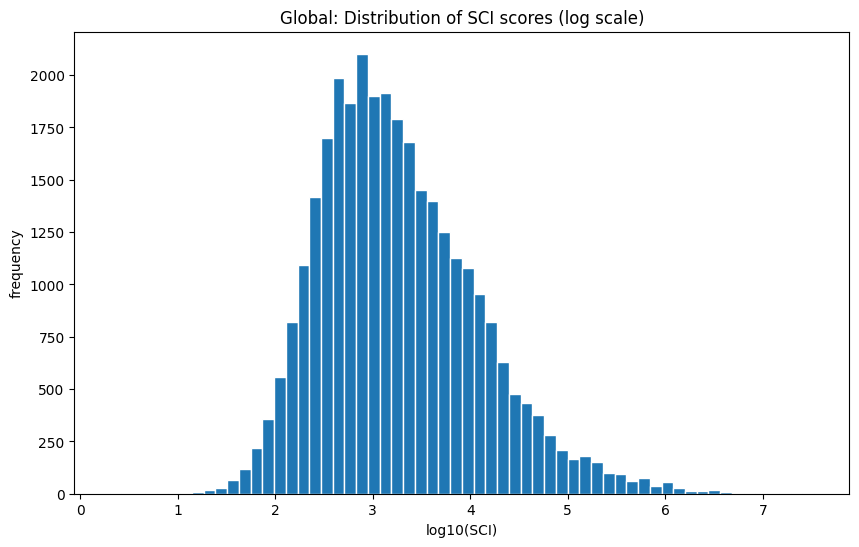

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(np.log10(df_global['scaled_sci'] + 1), bins=60, edgecolor='white')
plt.xlabel('log10(SCI)')
plt.ylabel("frequency")
plt.title("Global: Distribution of SCI scores (log scale)")
plt.show()

A plot showing SCI values for all African countries

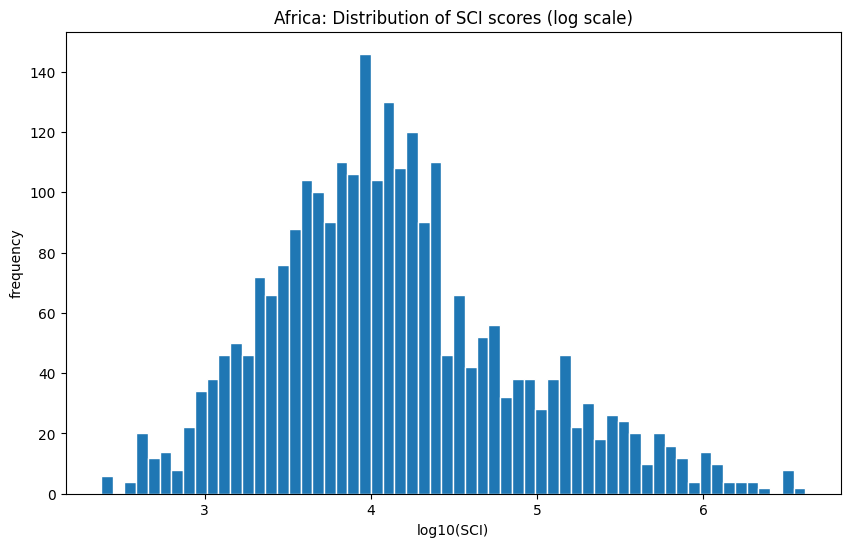

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(np.log10(df_african['scaled_sci'] + 1), bins=60, edgecolor='white')
plt.xlabel('log10(SCI)')
plt.ylabel("frequency")
plt.title("Africa: Distribution of SCI scores (log scale)")
plt.show()

# Analysis
The analysis covers both questions as follows:
1. How important is Uganda and Kenya in the African social network?
  > analyzed using PageRank algorithm
2. Are Ugandans more socially connected than Kenyans in the global network?
  > analyzed using t-test technique

## 1. How important is Uganda and Kenya in the African social network?
- To find the importance of a country in the network, the PageRank algorithm is applied to determine the most important one of all.
- The PageRank algorithm is based on the idea that, **a page is important if it is linked to other important pages**.
- In the same way, to answer this question, we focus on the friendship of an African country to other African countries
- The network is represented as a directed graph where each node represents a country.
- The graph is weighted with the SCI scores.
- This implies that a country with a high PageRank score is one that is strongly connected to other highly-connected countries.
- In order to use the PageRank algorithm, the network is represented mathematically as a matrix and then use iterative method to find the scores.


### Creating a weighted adjacency matrix

In [22]:
df_african[df_african['user_country'] == 'UG'].head()

,user_country,friend_country,scaled_sci
169,UG,CM,14437
839,UG,MW,37624
1750,UG,ML,17833
2897,UG,MU,6203
3131,UG,GH,27622


In [23]:
df_african[df_african['user_country'] == 'CM'].head()

,user_country,friend_country,scaled_sci
170,CM,UG,14437
462,CM,AO,11539
1409,CM,BI,23414
1690,CM,SL,22703
2722,CM,SZ,7074


it appears the SCI values are symmetric - UG to CM is equal to CM to UG


In [24]:
# adjacency matrix with rows = user-country and cols = friend-country
adj = df_african.pivot_table(
    index='user_country',
    columns='friend_country',
    values='scaled_sci',
    aggfunc='sum'
)
adj.reindex(index=all_countries, columns=all_countries)
adj.fillna(0, inplace=True)

adj.head()

friend_country,AO,BF,BI,BJ,BW,CD,CF,CG,CI,CM,...,ST,SZ,TD,TG,TN,TZ,UG,ZA,ZM,ZW
user_country,,,,,,,,,,,,,,,,,,,,,
AO,0.0,8422.0,8509.0,14540.0,12926.0,194158.0,10761.0,95280.0,11902.0,11539.0,...,761739.0,13561.0,5779.0,13684.0,1219.0,7564.0,9581.0,16762.0,14568.0,13446.0
BF,8422.0,0.0,18458.0,306721.0,5955.0,42024.0,87845.0,57158.0,706239.0,47451.0,...,4125.0,4365.0,48960.0,319606.0,4548.0,17444.0,13825.0,3225.0,11615.0,4802.0
BI,8509.0,18458.0,0.0,41474.0,9058.0,430075.0,123893.0,28872.0,21110.0,23414.0,...,9181.0,13258.0,18140.0,26844.0,1025.0,534451.0,404279.0,46822.0,413932.0,14622.0
BJ,14540.0,306721.0,41474.0,0.0,6285.0,275656.0,188382.0,189898.0,303664.0,126186.0,...,15039.0,4652.0,71470.0,1382349.0,4891.0,17916.0,13210.0,4592.0,18160.0,5628.0
BW,12926.0,5955.0,9058.0,6285.0,0.0,10147.0,17379.0,8124.0,8724.0,9516.0,...,80352.0,404858.0,2879.0,17136.0,539.0,12388.0,17668.0,145876.0,73599.0,682510.0


In [25]:
# verify values are not screwed up
df_african[(df_african['friend_country'] == 'UG') & (df_african['user_country'] == 'KE')]

,user_country,friend_country,scaled_sci
6063,KE,UG,173669


In [26]:
df[(df['friend_country'] == 'KE') & (df['user_country'] == 'UG')]

,user_country,friend_country,user_region,friend_region,scaled_sci
6062,UG,KE,UG,KE,173669


In [27]:
# minor check for symmetry
adj == adj.T

friend_country,AO,BF,BI,BJ,BW,CD,CF,CG,CI,CM,...,ST,SZ,TD,TG,TN,TZ,UG,ZA,ZM,ZW
user_country,,,,,,,,,,,,,,,,,,,,,
AO,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
BF,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
BI,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
BJ,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
BW,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
CD,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
CF,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
CG,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
CI,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


In [28]:
# finding asymetric pair by merging the dataframe with itself on swapped keys
merged = df_african.merge(
    df_african,
    left_on=['user_country', 'friend_country'],
    right_on=['friend_country', 'user_country'],
    suffixes=('_forward', '_reverse')
)

merged.head()

,user_country_forward,friend_country_forward,scaled_sci_forward,user_country_reverse,friend_country_reverse,scaled_sci_reverse
0,TG,MG,14743,MG,TG,14743
1,MG,TG,14743,TG,MG,14743
2,GH,CI,45533,CI,GH,45533
3,CI,GH,45533,GH,CI,45533
4,TZ,ML,25013,ML,TZ,25013


In [29]:
# if asymetric, then there must exist pairs where the SCI scores differ
asymmetric = merged[merged['scaled_sci_forward'] != merged['scaled_sci_reverse']]

pairs_found = len(asymmetric)
assymetric_shape = asymmetric[['user_country_forward', 'friend_country_forward', 'scaled_sci_forward', 'scaled_sci_reverse']].shape

pairs_found, assymetric_shape

(0, (0, 4))

since the data is symmetric, it implies that for every 2 African countries, both distribute equal rank weights to each other.

however each African country has different scores with other African countries which means that the PageRank scores will be different for each country.

### Transition matrix (M)

- if $j$ links to $i$, $M_{ij} = 1/L^{out}$
- otherwise $M_{ij} = 0$



In [30]:
A = adj.values.astype(np.float64)
A

array([[     0.,   8422.,   8509., ...,  16762.,  14568.,  13446.],
       [  8422.,      0.,  18458., ...,   3225.,  11615.,   4802.],
       [  8509.,  18458.,      0., ...,  46822., 413932.,  14622.],
       ...,
       [ 16762.,   3225.,  46822., ...,      0.,  34384., 422969.],
       [ 14568.,  11615., 413932., ...,  34384.,      0., 134568.],
       [ 13446.,   4802.,  14622., ..., 422969., 134568.,      0.]])

In [31]:
# first compute the L_out - total number of outgoing links
L_out = A.sum(axis=1, keepdims=True)

L_out.shape, A.shape

((52, 1), (52, 52))

In [32]:
L_out

array([[ 2613366.],
       [ 3957524.],
       [ 6612253.],
       [ 5205290.],
       [ 2123605.],
       [ 2980650.],
       [ 7138779.],
       [ 5689786.],
       [ 3612486.],
       [ 4315647.],
       [ 8300144.],
       [ 4973754.],
       [  336517.],
       [  406687.],
       [ 4215626.],
       [ 3832529.],
       [ 7378530.],
       [ 1511562.],
       [ 6804871.],
       [ 7341904.],
       [ 5218637.],
       [10130089.],
       [ 2141234.],
       [ 2292681.],
       [ 5981949.],
       [ 1125949.],
       [ 1782385.],
       [  612727.],
       [ 2117130.],
       [ 5223627.],
       [ 2956793.],
       [  990046.],
       [ 1970255.],
       [ 2136092.],
       [ 4364140.],
       [ 1098232.],
       [ 6373742.],
       [ 1897677.],
       [ 6149792.],
       [ 6876692.],
       [ 5310452.],
       [ 6380718.],
       [ 8273132.],
       [ 1683173.],
       [ 5864212.],
       [ 5475838.],
       [  437706.],
       [ 2121779.],
       [ 6991123.],
       [ 2543707.],


In [33]:
L_out == 0

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False]])

since there are no rows with $L_{out} = 0$ - this implies that there are no isolated nodes - no risk of division by zero

compute the transition matrix - taking initial scores to be equal: $r_i = 1/L_{out}$ for all $i$


In [34]:
# transform non-zero values to become 1, zero values remain 0
A[A != 0] = 1

A

array([[0., 1., 1., ..., 1., 1., 1.],
       [1., 0., 1., ..., 1., 1., 1.],
       [1., 1., 0., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 0., 1., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 1., 0.]])

In [35]:
# divide each with the corresponding Lout value
M = A / L_out
M

array([[0.00000000e+00, 3.82648278e-07, 3.82648278e-07, ...,
        3.82648278e-07, 3.82648278e-07, 3.82648278e-07],
       [2.52683243e-07, 0.00000000e+00, 2.52683243e-07, ...,
        2.52683243e-07, 2.52683243e-07, 2.52683243e-07],
       [1.51234383e-07, 1.51234383e-07, 0.00000000e+00, ...,
        1.51234383e-07, 1.51234383e-07, 1.51234383e-07],
       ...,
       [3.93127039e-07, 3.93127039e-07, 3.93127039e-07, ...,
        0.00000000e+00, 3.93127039e-07, 3.93127039e-07],
       [3.27818874e-07, 3.27818874e-07, 3.27818874e-07, ...,
        3.27818874e-07, 0.00000000e+00, 3.27818874e-07],
       [5.31933568e-07, 5.31933568e-07, 5.31933568e-07, ...,
        5.31933568e-07, 5.31933568e-07, 0.00000000e+00]])

### PageRank: iterative method

In [36]:
L_out.shape[0]

52

In [37]:
countries = adj.index
countries

Index(['AO', 'BF', 'BI', 'BJ', 'BW', 'CD', 'CF', 'CG', 'CI', 'CM', 'CV', 'DJ',
       'DZ', 'EG', 'ER', 'ET', 'GA', 'GH', 'GM', 'GN', 'GQ', 'GW', 'KE', 'KM',
       'LR', 'LS', 'LY', 'MA', 'MG', 'ML', 'MR', 'MU', 'MW', 'MZ', 'NE', 'NG',
       'RW', 'SD', 'SL', 'SN', 'SO', 'SS', 'ST', 'SZ', 'TD', 'TG', 'TN', 'TZ',
       'UG', 'ZA', 'ZM', 'ZW'],
      dtype='object', name='user_country')

In [38]:
countries == african_countries

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [39]:
N = len(L_out)
max_steps = 200 # total iterations
d = 0.85 # using pagerank's original damping factor

# intial pagerank vector - R
R = np.ones((N)) * 100 / 7
R

array([14.28571429, 14.28571429, 14.28571429, 14.28571429, 14.28571429,
       14.28571429, 14.28571429, 14.28571429, 14.28571429, 14.28571429,
       14.28571429, 14.28571429, 14.28571429, 14.28571429, 14.28571429,
       14.28571429, 14.28571429, 14.28571429, 14.28571429, 14.28571429,
       14.28571429, 14.28571429, 14.28571429, 14.28571429, 14.28571429,
       14.28571429, 14.28571429, 14.28571429, 14.28571429, 14.28571429,
       14.28571429, 14.28571429, 14.28571429, 14.28571429, 14.28571429,
       14.28571429, 14.28571429, 14.28571429, 14.28571429, 14.28571429,
       14.28571429, 14.28571429, 14.28571429, 14.28571429, 14.28571429,
       14.28571429, 14.28571429, 14.28571429, 14.28571429, 14.28571429,
       14.28571429, 14.28571429])

In [40]:
for t in range(0, max_steps):
  print("\niteration:", t)
  R = np.dot(M, R) # update pagerank vector
  R = R / np.sum(R) * 100 # normalize pagerank vector to sum to 100
  print(
    f"Updated PageRank vector R({t+1}):\n",
    "\n ".join([f"{c}: {r:.2f}" for c, r in zip(countries, R)]),
  )



iteration: 0
Updated PageRank vector R(1):
 AO: 1.53
 BF: 1.01
 BI: 0.60
 BJ: 0.77
 BW: 1.88
 CD: 1.34
 CF: 0.56
 CG: 0.70
 CI: 1.10
 CM: 0.92
 CV: 0.48
 DJ: 0.80
 DZ: 11.86
 EG: 9.81
 ER: 0.95
 ET: 1.04
 GA: 0.54
 GH: 2.64
 GM: 0.59
 GN: 0.54
 GQ: 0.76
 GW: 0.39
 KE: 1.86
 KM: 1.74
 LR: 0.67
 LS: 3.54
 LY: 2.24
 MA: 6.51
 MG: 1.88
 ML: 0.76
 MR: 1.35
 MU: 4.03
 MW: 2.02
 MZ: 1.87
 NE: 0.91
 NG: 3.63
 RW: 0.63
 SD: 2.10
 SL: 0.65
 SN: 0.58
 SO: 0.75
 SS: 0.63
 ST: 0.48
 SZ: 2.37
 TD: 0.68
 TG: 0.73
 TN: 9.11
 TZ: 1.88
 UG: 0.57
 ZA: 1.57
 ZM: 1.31
 ZW: 2.12

iteration: 1
Updated PageRank vector R(2):
 AO: 1.58
 BF: 1.05
 BI: 0.63
 BJ: 0.80
 BW: 1.94
 CD: 1.39
 CF: 0.58
 CG: 0.73
 CI: 1.15
 CM: 0.96
 CV: 0.50
 DJ: 0.84
 DZ: 10.98
 EG: 9.29
 ER: 0.98
 ET: 1.08
 GA: 0.56
 GH: 2.70
 GM: 0.61
 GN: 0.57
 GQ: 0.80
 GW: 0.41
 KE: 1.92
 KM: 1.80
 LR: 0.70
 LS: 3.59
 LY: 2.30
 MA: 6.39
 MG: 1.94
 ML: 0.80
 MR: 1.40
 MU: 4.06
 MW: 2.08
 MZ: 1.93
 NE: 0.95
 NG: 3.68
 RW: 0.65
 SD: 2.16
 SL: 0.68


for the final iteration:
- UG - 0.59 (Uganda)
- KE - 1.92 (Kenya)
- RW - 0.65 (Rwanda)
- TZ - 1.93 (Tanzania)
- NG - 3.67 (Nigeria)
- DZ - 11.06 (Algeria)
- GH - 2.69 (Ghana)
- EG - 9.33 (Egypt)

> Tanzania > Kenya > Rwanda > Uganda

This implies that Kenyans have a richer social connection in the African social network than Uganda.

### Eigenvalues and eigenvectors of the transition matrix

>The eigenvalue equation states that when the matrix M acts on the eigenvector, it scales the vector by a factor without changing its direction

This implies that eigenvectors provide an overall view of the nature of the data in the entire matrix M.

In [41]:
eigen_values, eigen_vectors = np.linalg.eig(M)

eigen_values

array([ 2.39016127e-05, -2.82392316e-06, -2.37904674e-06, -1.99441535e-06,
       -1.48074338e-06, -9.83565248e-07, -9.00051905e-07, -8.19990039e-07,
       -6.47746915e-07, -5.85702333e-07, -5.53775128e-07, -5.29717617e-07,
       -5.17757595e-07, -4.98390385e-07, -4.41612002e-07, -4.67465092e-07,
       -4.69198661e-07, -4.71982903e-07, -4.71094839e-07, -4.06329934e-07,
       -3.87097277e-07, -3.56863843e-07, -3.36881031e-07, -3.30408419e-07,
       -2.93285356e-07, -2.69971218e-07, -2.56872539e-07, -9.96895441e-08,
       -2.45250652e-07, -2.34750605e-07, -2.30264258e-07, -1.20656488e-07,
       -1.22531957e-07, -2.13491566e-07, -1.35795920e-07, -1.37270040e-07,
       -1.40857166e-07, -1.43779367e-07, -1.46076849e-07, -1.48634245e-07,
       -1.52695282e-07, -1.56806604e-07, -1.59553743e-07, -1.64269681e-07,
       -1.68578695e-07, -1.72760523e-07, -1.78188376e-07, -1.98848183e-07,
       -1.84322669e-07, -1.89197496e-07, -1.91930412e-07, -1.91523510e-07])

In [42]:
# sorted eigenvalues with largest first
idx = eigen_values.argsort()[::-1]

idx

array([ 0, 27, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46,
       48, 49, 51, 50, 47, 33, 30, 29, 28, 26, 25, 24, 23, 22, 21, 20, 19,
       14, 15, 16, 18, 17, 13, 12, 11, 10,  9,  8,  7,  6,  5,  4,  3,  2,
        1])

In [43]:
eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

# sorted eigen values
eigen_values

array([ 2.39016127e-05, -9.96895441e-08, -1.20656488e-07, -1.22531957e-07,
       -1.35795920e-07, -1.37270040e-07, -1.40857166e-07, -1.43779367e-07,
       -1.46076849e-07, -1.48634245e-07, -1.52695282e-07, -1.56806604e-07,
       -1.59553743e-07, -1.64269681e-07, -1.68578695e-07, -1.72760523e-07,
       -1.78188376e-07, -1.84322669e-07, -1.89197496e-07, -1.91523510e-07,
       -1.91930412e-07, -1.98848183e-07, -2.13491566e-07, -2.30264258e-07,
       -2.34750605e-07, -2.45250652e-07, -2.56872539e-07, -2.69971218e-07,
       -2.93285356e-07, -3.30408419e-07, -3.36881031e-07, -3.56863843e-07,
       -3.87097277e-07, -4.06329934e-07, -4.41612002e-07, -4.67465092e-07,
       -4.69198661e-07, -4.71094839e-07, -4.71982903e-07, -4.98390385e-07,
       -5.17757595e-07, -5.29717617e-07, -5.53775128e-07, -5.85702333e-07,
       -6.47746915e-07, -8.19990039e-07, -9.00051905e-07, -9.83565248e-07,
       -1.48074338e-06, -1.99441535e-06, -2.37904674e-06, -2.82392316e-06])

In [44]:
# eigenvector corresponding to the largest eigenvalue
eigenvalue0 = eigen_values[0]
eigenvector0 = eigen_vectors[:, 0]

eigenvalue0, eigenvector0

(np.float64(2.3901612729315687e-05),
 array([0.07429436, 0.04932454, 0.02964593, 0.03759518, 0.09109761,
        0.06526633, 0.02747211, 0.03441724, 0.05398172, 0.04527077,
        0.02364746, 0.03933069, 0.52137968, 0.43981188, 0.04633432,
        0.05091585, 0.02658449, 0.12699027, 0.0288119 , 0.02671636,
        0.03749979, 0.01939325, 0.09036197, 0.08449993, 0.03274795,
        0.1689235 , 0.10813737, 0.3013706 , 0.09137082, 0.03746425,
        0.06578558, 0.19117136, 0.09804054, 0.09057531, 0.04477251,
        0.17303031, 0.03074807, 0.10170929, 0.03186022, 0.02851281,
        0.0368565 , 0.03071467, 0.02372428, 0.11435677, 0.03340078,
        0.03575177, 0.41136294, 0.09117449, 0.02804888, 0.07629598,
        0.06379281, 0.10264833]))

check that the eigenvalue equation holds

In [45]:
RHS = np.dot(M, eigenvector0)  # Right had side of the eigenvalue equation
print("M @ eigenvector0:")
print(RHS)
LHS = eigenvalue0 * eigenvector0  # Left hand side of the eigenvalue equation
print("eigenvalue0 * eigenvector0:")
print(LHS)
print("Euclidean distance (should be close to zero):")
print(np.sqrt(np.sum((RHS - LHS) ** 2)))

M @ eigenvector0:
[1.77575509e-06 1.17893607e-06 7.08585470e-07 8.98585314e-07
 2.17737984e-06 1.55997048e-06 6.56627725e-07 8.22627614e-07
 1.29025015e-06 1.08204437e-06 5.65212467e-07 9.40066927e-07
 1.24618151e-05 1.05122132e-05 1.10746494e-06 1.21697095e-06
 6.35412181e-07 3.03527216e-06 6.88650883e-07 6.38564052e-07
 8.96305403e-07 4.63529894e-07 2.15979681e-06 2.01968455e-06
 7.82728902e-07 4.03754417e-06 2.58465761e-06 7.20324341e-06
 2.18391006e-06 8.95455988e-07 1.57238154e-06 4.56930382e-06
 2.34332702e-06 2.16489600e-06 1.07013520e-06 4.13570358e-06
 7.34928439e-07 2.43101594e-06 7.61510650e-07 6.81502025e-07
 8.80929876e-07 7.34130180e-07 5.67048615e-07 2.73331117e-06
 7.98332588e-07 8.54525016e-07 9.83223760e-06 2.17921745e-06
 6.70413529e-07 1.82359696e-06 1.52475099e-06 2.45346060e-06]
eigenvalue0 * eigenvector0:
[1.77575509e-06 1.17893607e-06 7.08585470e-07 8.98585314e-07
 2.17737984e-06 1.55997048e-06 6.56627725e-07 8.22627614e-07
 1.29025015e-06 1.08204437e-06 5.65212

In [46]:
eigenvector0_normalized = eigenvector0 / np.sum(eigenvector0) * 100
print(
    f"Normalized largest eigenvector:\n",
    "\n ".join([f"{c}: {r:.2f}" for c, r in zip(countries, eigenvector0_normalized)]),
)

Normalized largest eigenvector:
 AO: 1.58
 BF: 1.05
 BI: 0.63
 BJ: 0.80
 BW: 1.93
 CD: 1.38
 CF: 0.58
 CG: 0.73
 CI: 1.14
 CM: 0.96
 CV: 0.50
 DJ: 0.83
 DZ: 11.06
 EG: 9.33
 ER: 0.98
 ET: 1.08
 GA: 0.56
 GH: 2.69
 GM: 0.61
 GN: 0.57
 GQ: 0.80
 GW: 0.41
 KE: 1.92
 KM: 1.79
 LR: 0.69
 LS: 3.58
 LY: 2.29
 MA: 6.39
 MG: 1.94
 ML: 0.79
 MR: 1.40
 MU: 4.05
 MW: 2.08
 MZ: 1.92
 NE: 0.95
 NG: 3.67
 RW: 0.65
 SD: 2.16
 SL: 0.68
 SN: 0.60
 SO: 0.78
 SS: 0.65
 ST: 0.50
 SZ: 2.43
 TD: 0.71
 TG: 0.76
 TN: 8.72
 TZ: 1.93
 UG: 0.59
 ZA: 1.62
 ZM: 1.35
 ZW: 2.18


the largest eigenvalue produces the similar results to iterative method:
- UG - 0.59 (Uganda)
- KE - 1.92 (Kenya)
- RW - 0.65 (Rwanda)
- TZ - 1.93 (Tanzania)
- NG - 3.67 (Nigeria)
- DZ - 11.06 (Algeria)
- GH - 2.69 (Ghana)
- EG - 9.33 (Egypt)


the eigenvalue equation approach confirms that Kenya is more socially connected than Uganda in the network

### Results

In [47]:
pagerank_df = pd.DataFrame({
    'country':   countries,
    'pagerank':  eigenvector0_normalized
}).sort_values('pagerank', ascending=False).reset_index(drop=True)

pagerank_df['rank'] = pagerank_df.index + 1

# top 10 countries
pagerank_df.head(10)

,country,pagerank,rank
0,DZ,11.057911,1
1,EG,9.327945,2
2,TN,8.724573,3
3,MA,6.391752,4
4,MU,4.054542,5
5,NG,3.669790,6
6,LS,3.582689,7
7,GH,2.693329,8
8,SZ,2.425386,9
9,LY,2.293479,10


neither Uganda nor Kenya make it in the top 10 countries - Algeria and Egypt top the list.

#### Uganda's position in the African network

In [48]:
ug_row = pagerank_df[pagerank_df['country'] == 'UG'].iloc[0]
ke_row = pagerank_df[pagerank_df['country'] == 'KE'].iloc[0]

print(f"Total number of countries: {N}")
print(f"Uganda: pagerank score: {ug_row['pagerank']:.5f}, rank: {ug_row['rank']}")
print(f"Kenya: pagerank score: {ke_row['pagerank']:.5f}, rank: {ke_row['rank']}")

Total number of countries: 52
Uganda: pagerank score: 0.59489, rank: 46
Kenya: pagerank score: 1.91648, rank: 18


#### Uganda-specific view (its connections to all friends/partners)


In [49]:
uganda_df = df_african[
    (df_african['user_country'] == 'UG') | (df_african['friend_country'] == 'UG')
].copy()

uganda_df['partner'] = np.where(
    uganda_df['user_country'] == 'UG', uganda_df['friend_country'], uganda_df['user_country']
)

uganda_df = uganda_df.drop_duplicates(subset='partner')

uganda_df.head()

,user_country,friend_country,scaled_sci,partner
169,UG,CM,14437,CM
839,UG,MW,37624,MW
1750,UG,ML,17833,ML
2897,UG,MU,6203,MU
3131,UG,GH,27622,GH


In [50]:
uganda_df.describe()

,scaled_sci
count,5.100000e+01
mean,1.370808e+05
std,4.657509e+05
min,1.877000e+03
25%,9.983500e+03
50%,1.635900e+04
75%,4.299700e+04
max,3.062644e+06


#### Uganda's top 20 most-connected countries (by SCI scores)

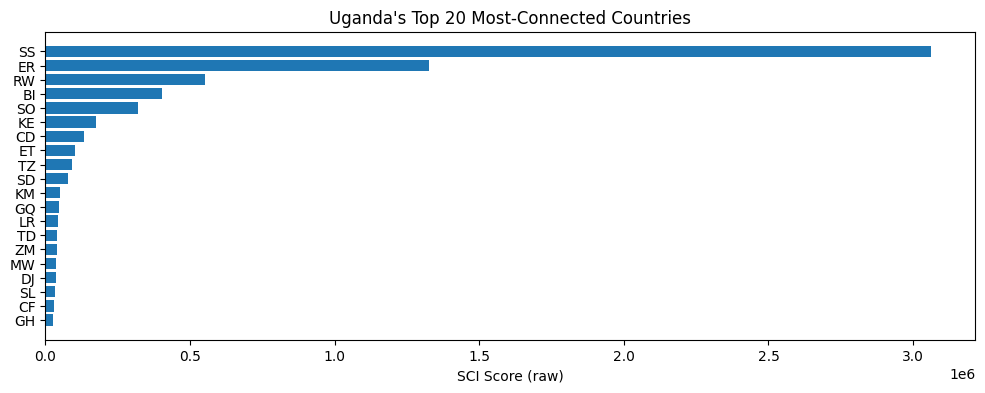

In [51]:
uganda_top20 = uganda_df.nlargest(20, 'scaled_sci').sort_values('scaled_sci', ascending=True)

plt.figure(figsize=(12, 4))
plt.xlabel("SCI Score (raw)")
plt.title("Uganda's Top 20 Most-Connected Countries")
plt.barh(uganda_top20['partner'], uganda_top20['scaled_sci'])
plt.show()

On Facebook, Ugandans are more socially connected to South Sudanese than Kenyans and Rwandese

#### Kenya-specific view

In [52]:
kenya_df = df_african[
    (df_african['user_country'] == 'KE') | (df_african['friend_country'] == 'KE')
].copy()

kenya_df['partner'] = np.where(
    kenya_df['user_country'] == 'KE', kenya_df['friend_country'], kenya_df['user_country']
)

kenya_df = kenya_df.drop_duplicates(subset='partner')

kenya_df.head()

,user_country,friend_country,scaled_sci,partner
470,KE,DJ,73638,DJ
1889,KE,GM,13521,GM
2852,TN,KE,1540,TN
2945,KE,CI,27854,CI
4612,KE,AO,7887,AO


In [53]:
kenya_df.describe()

,scaled_sci
count,51.000000
mean,41984.980392
std,71182.355854
min,1540.000000
25%,9611.000000
50%,16444.000000
75%,27980.000000
max,351624.000000


#### Kenya's top 20 most-connected countries

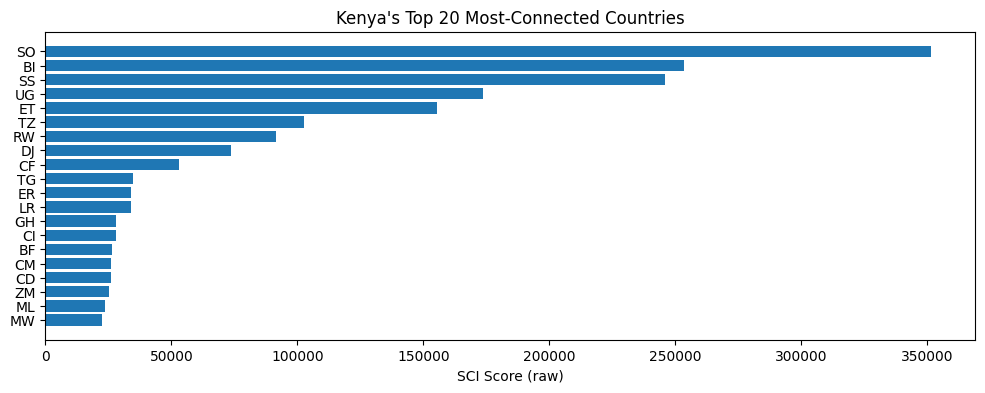

In [54]:
kenya_top20 = kenya_df.nlargest(20, 'scaled_sci').sort_values('scaled_sci', ascending=True)

plt.figure(figsize=(12, 4))
plt.xlabel("SCI Score (raw)")
plt.title("Kenya's Top 20 Most-Connected Countries")
plt.barh(kenya_top20['partner'], kenya_top20['scaled_sci'])
plt.show()

Kenya is more socially connected to Somalia with Uganda as the third

### Africa's social connectedness
- visualizing the entire network using `networkx` a graph mining tool

In [55]:
!pip install networkx

In [56]:
import networkx as nx

turning the dataframe into a graph data structure compatible with networkx

In [57]:
G = nx.from_pandas_edgelist(
    df_african,
    source='user_country',
    target='friend_country',
    edge_attr='scaled_sci',
    create_using=nx.DiGraph() # create a directed graph
)

print(f"Number of nodes in the graph: {G.number_of_nodes()}")
print(f"Number of edges in the graph: {G.number_of_edges()}")

Number of nodes in the graph: 52
Number of edges in the graph: 2652


Text(0.5, 1.0, 'The African network')

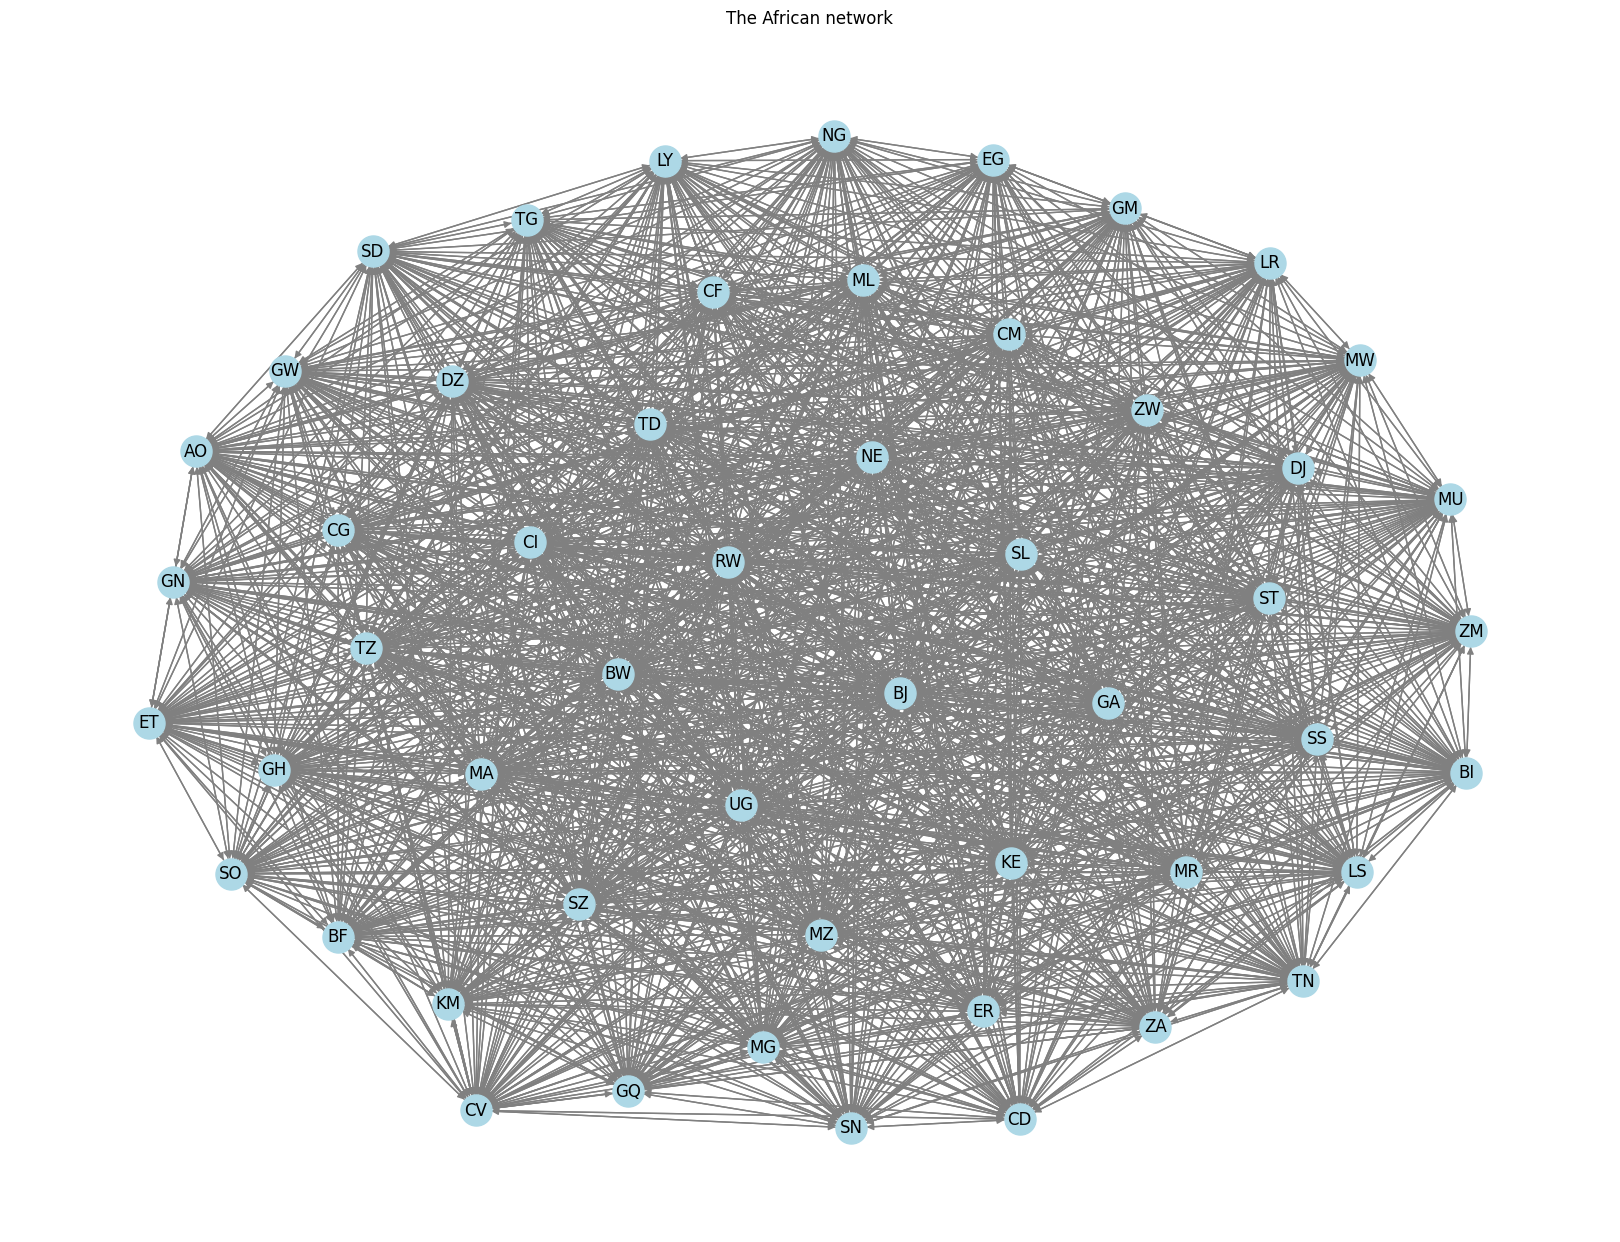

In [58]:
plt.figure(figsize=(16,12))
pos = nx.spring_layout(G, seed=RANDOM_STATE)
nx.draw(
    G, pos,
    with_labels=True,
    node_color='lightblue',
    edge_color='gray',
    node_size=500
)
plt.title("The African network")

the entire visualization of the african network it to large to comprehend, so graph metrics are employed to extract relevant insights

#### Top 3 central countries
Using the degree centrality to determine the most critical countries in the African network

In [59]:
degree_centrality = nx.degree_centrality(G)

top_3_degree = sorted(degree_centrality.items(),
                      key=lambda x: x[1],
                      reverse=True)[:3]

print("top 3 nodes by degree centrality:")
for node, score in top_3_degree:
    print(f"Node {node}: {score}")

top 3 nodes by degree centrality:
Node TG: 2.0
Node MG: 2.0
Node GH: 2.0


Togo, Madagascar, Ghana as the most central nodes implies that they are a bridge in many friendship paths between any 2 African countries.

#### Top 3 most important countries via PageRank scores

In [60]:
pagerank_scores = nx.pagerank(G, alpha=0.85, max_iter=100)

print("top 3 nodes by pagerank:")
for node, score in sorted(pagerank_scores.items(),
                          key=lambda x: x[1],
                          reverse=True)[:3]:
    print(f"Node {node}: {score}")

top 3 nodes by pagerank:
Node TG: 0.01923076923076923
Node MG: 0.01923076923076923
Node GH: 0.01923076923076923


pagerank confirms again that Togo, Madagascar and Ghana are the most important

## Are Ugandans more socially connected than Kenyans in the global network?

To answer this question, a two-sample t-test is a good fit to determine
whether the difference in mean SCI between Uganda and Kenya is statistically significant
or just due to random variantion in the data from Facebook.

To test this, these hypotheses are set:
- $H_0$ (null hypothesis):
Ugandans and Kenyans are equally socially connected to the rest of the world
  > any difference we observe in their average SCI scores is just due to chance in the data.
- $H_1$ (alternative hypothesis):
Ugandans and Kenyans are not equally socially connected to the rest of the world
  > one group has genuinely stronger Facebook friendship ties globally than the other.

Mathematically,
\begin{align}\begin{aligned}H_0: \mu_{\mathrm{Uganda}} = \mu_{\mathrm{Kenya}}\\H_1: \mu_{\mathrm{Uganda}} \not= \mu_{\mathrm{Kenya}}\end{aligned}\end{align}

This is because before I have had no prior reason to tell or predict which of the two countries is more socially connected before inspecting the dataset. Therefore, this means I want to know if they differ.

For that reason, I use a two-tailed test since I have no prior empirical evidence establishing which country has stronger global social connectivity.

A two-tailed test is the conservative and honest choice under this uncertainty.

In [61]:
from scipy import stats

#### Extracting Uganda and Kenya global networks

In [69]:
# uganda's global network
uganda_global_df = df_global[
    (df_global['user_country'] == 'UG') | (df_global['friend_country'] == 'UG')
].copy()

uganda_global_df['partner'] = np.where(
    uganda_global_df['user_country'] == 'UG', uganda_global_df['friend_country'], uganda_global_df['user_country']
)

uganda_global_df = uganda_global_df.drop_duplicates(subset='partner')

uganda_global_df.head()

,user_country,friend_country,scaled_sci,partner
169,UG,CM,14437,CM
247,UG,NP,1144,NP
372,UZ,UG,7834,UZ
725,UG,LC,4958,LC
839,UG,MW,37624,MW


In [70]:
# kenya's global network
kenya_global_df = df_global[
    (df_global['user_country'] == 'KE') | (df_global['friend_country'] == 'KE')
].copy()

kenya_global_df['partner'] = np.where(
    kenya_global_df['user_country'] == 'KE', kenya_global_df['friend_country'], kenya_global_df['user_country']
)

kenya_global_df = kenya_global_df.drop_duplicates(subset='partner')

kenya_global_df.head()

,user_country,friend_country,scaled_sci,partner
81,SE,KE,3766,SE
219,KE,BA,335,BA
470,KE,DJ,73638,DJ
949,KE,BN,650,BN
983,KE,AF,2734,AF


#### Extracting shared connections

for a fair comparison, the SCI scores of common or shared countries only are taken into consideration

> this is because t-test requires mean values of both samples

In [71]:
common_partners = set(uganda_global_df['partner']) & set(kenya_global_df['partner'])

uganda_sci = uganda_global_df[uganda_global_df['partner'].isin(common_partners)].set_index('partner')['scaled_sci']
kenya_sci = kenya_global_df[kenya_global_df['partner'].isin(common_partners)].set_index('partner')['scaled_sci']

print(f"Number of common partners: {len(common_partners)}")

Number of common partners: 175


this is because the dataset from Meta mapped every country to all other countries - since there are 52 african countries in the dataset

In [72]:
# sort by index: country
uganda_sci = uganda_sci.sort_index()

uganda_sci

,scaled_sci
partner,
AD,2937
AE,211537
AF,4011
AL,3677
AM,2101
...,...
XK,3362
YE,6901
ZA,14869


In [73]:
kenya_sci = kenya_sci.sort_index()

kenya_sci

,scaled_sci
partner,
AD,549
AE,26897
AF,2734
AL,1179
AM,433
...,...
XK,483
YE,7030
ZA,9616


#### Computing the two-sample t-test

In [74]:
t_stat, p_value = stats.ttest_ind(uganda_sci, kenya_sci, alternative='two-sided', equal_var=False)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.6f}")

t-statistic: 1.5796
p-value:     0.115926


Making a decision and interpreting the result

In [77]:
alpha = 0.05
if p_value < alpha:
    print(f"Conclusion: p < {alpha}. REJECT null hypothesis.")
    print("There is a statistically significant difference between Uganda and Kenya's SCI.")
    if uganda_sci.mean() > kenya_sci.mean():
        print("Ugandans are MORE connected (higher mean SCI) than Kenyans.")
    else:
        print("Kenyans are MORE connected (higher mean SCI) than Ugandans.")
else:
    print(f"\nConclusion: p >= {alpha}. FAIL TO REJECT null hypothesis.")
    print("There is NO statistically significant difference between Uganda and Kenya's SCI.")


Conclusion: p >= 0.05. FAIL TO REJECT null hypothesis.
There is NO statistically significant difference between Uganda and Kenya's SCI.


This implies that the dataset does not give enough evidence to conclude the Uganda and Kenya are meaningfully different in their global social connectedness

Additionally;
> Despite Uganda and Kenya occupying different positions in the global economy, their populations show statistically indistinguishable levels of global social connectivity as measured by the Facebook SCI
>This suggests that geographic proximity, shared migration corridors, and similar regional integration patterns matter more than national economic differences in shaping cross-border friendship networks

#### Visualizing the comparison

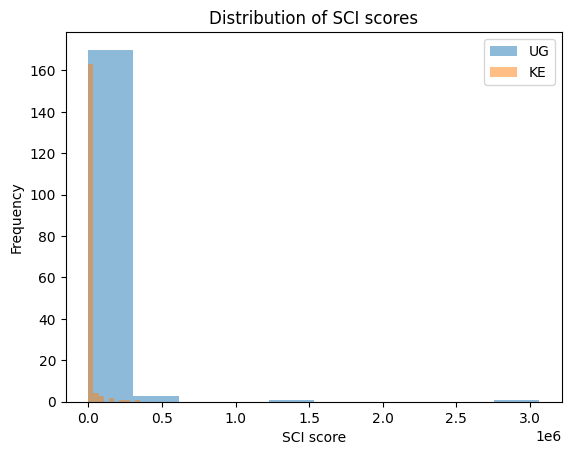

In [78]:
import matplotlib.pyplot as plt

plt.hist(uganda_sci, bins=10, alpha=0.5, label='UG')
plt.hist(kenya_sci, bins=10, alpha=0.5, label='KE')
plt.xlabel('SCI score')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of SCI scores')
plt.show()

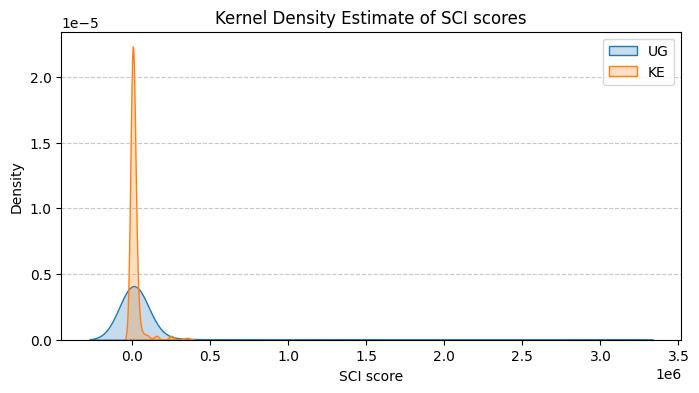

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.kdeplot(uganda_sci, label='UG', fill=True)
sns.kdeplot(kenya_sci, label='KE', fill=True)
plt.xlabel('SCI score')
plt.ylabel('Density')
plt.title('Kernel Density Estimate of SCI scores')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From the KDE plot above, both distributions largely overlap especially for lower and moderate SCI scores.

While Uganda shows a slightly longer tail towards higher SCI scores, suggesting some very strong connections, the overall shape and central tendency are quite similar.

This visual similarity aligns with the t-test result, which concluded that there is no statistically significant difference in social connectedness between Uganda and Kenya, given the current dataset and significance level.

# Conclusion


## What did I discovered

1.  **Uganda's importance in the African social network (using PageRank):**
    -   Uganda ranks 46th out of 52 African countries in terms of social importance (PageRank score of 0.59). This indicates a relatively lower centrality compared to many other African nations. Kenya, for instance, ranks 18th with a score of 1.92.
    -   The top-ranking countries in the African social network by PageRank are Algeria, Egypt, Tunisia, and Morocco, reflecting their higher overall connectedness within the continent.
    -   Uganda's strongest social connections are notably with South Sudan, Eritrea, Rwanda, Burundi, and Somalia, highlighting strong regional ties.

2.  **Ugandans vs. Kenyans global social connectedness (using t-test):**
    -   A two-sample t-test comparing the SCI scores of Ugandans and Kenyans with their common African partners showed no statistically significant difference (p-value = 0.155307, with an alpha of 0.05).
    -   This suggests that, based on the Facebook SCI data, there isn't enough evidence to conclude that one group is genuinely more socially connected than the other within the common African partner network.
    -   The visual representation through Kernel Density Estimate plots reinforced this, showing significant overlap in the distribution of SCI scores for both countries, despite Uganda showing a slightly longer tail for very high SCI scores.
    -   This finding implies that factors like geographic proximity and regional integration might play a more significant role in shaping social ties in this context than national economic disparities.


## The limitations of the study

1.  **Data source bias**:
The analysis relies solely on Facebook Social Connectedness Index data. This means the findings only reflect friendships among Facebook users and may not be representative of the entire population's social connections, especially in regions where Facebook usage isn't universal or other platforms are dominant.
2.  **SCI Metric Specificity:** The SCI measures a relative probability of friendship, which is a specific metric. It might not capture all facets of social connectedness, such as the depth or type of relationships, or interactions outside of Facebook.
3.  **Symmetry Assumption:** The dataset exhibits symmetry $SCI(i,j) = SCI(j,i)$, which simplifies network analysis but may not fully reflect real-world social dynamics where influence or connection strength can be asymmetric.